In [1]:
import os
import sys
from dotenv import load_dotenv
from pathlib import Path
import datetime

import pandas as pd
import numpy as np
from math import exp, sqrt
import random
import matplotlib.pyplot as plt

prophet_site_packages = "/tmp/prophet-venv/lib/python3.10/site-packages"
if prophet_site_packages not in sys.path:
    sys.path.insert(0, prophet_site_packages)

from prophet import Prophet

/tmp/prophet-venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# environment variables
env_path = Path("/home/jovyan/.env")
load_dotenv(env_path)

# mounted data directory in container
data_path = Path("/home/jovyan/data/data-main")

print("cwd:", Path.cwd())
print("data_path:", data_path)
print("exists:", data_path.exists())

cwd: /home/jovyan
data_path: /home/jovyan/data/data-main
exists: True


## 株価の予測 -- モンテカルロ法と時系列モデル

In [3]:
# finance/data/data-main/5_nikkei225_data.csv
nikkei = pd.read_csv(data_path / "5_nikkei225_data.csv", parse_dates=True).sort_index()
nikkei = nikkei.set_index("Date")
nikkei.head()

,nikkei
Date,
2021/1/4,27258.38
2021/1/5,27158.63
2021/1/6,27055.94
2021/1/7,27490.13
2021/1/8,28139.03


### モンテカルロ法による日経平均株価の予測

### モンテカルロ・シミュレーションのモデル

このセクションでは、日次対数収益率を用いた幾何ブラウン運動（GBM）で株価をシミュレーションします。

- 対数収益率:
  $$
  r_t = \log(S_t) - \log(S_{t-1})
  $$
- 年率化した平均・標準偏差:
  $$
  \mu = 250 \cdot \mathbb{E}[r_t], \qquad \sigma = \sqrt{250}\cdot \mathrm{Std}(r_t)
  $$
- 1ステップ先の株価更新式（離散化GBM）:
  $$
  S_{t+\Delta t} = S_t\exp\left(\left(\mu-\frac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\,Z_t\right), \quad Z_t\sim\mathcal{N}(0,1)
  $$

この更新式を営業日数 $p$ だけ繰り返し、さらにそれを $q$ 回反復して終値分布を得ます。

In [4]:
# [3]データの前処理
d_nikkei = np.log(nikkei.nikkei).diff(1)
last = nikkei.nikkei[-1]

/tmp/ipykernel_786/1435170366.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last = nikkei.nikkei[-1]


In [5]:
# [4] リターン・平均値・標準偏差の算出と変数の定義
days = 250
mu = np.mean(d_nikkei) * days
sigma = np.std(d_nikkei) * sqrt(days)
delta_t = 1 / days
z = random.gauss(mu, sigma)

In [6]:
# [5]株価変動モデルの定義
def bsm(S, sigma, mu, delta_t, z):
    bsm = S * exp((mu - sigma ** 2/2) * delta_t + sigma * sqrt(delta_t) * z)
    return bsm

In [7]:
# [6]予測期間(p)・反転回数(q)・初期値他の定義と設定
p, q = 270, 10000
nikkei_F = np.zeros(p)
nikkei_F[0] = last
nikkei_F2 = np.zeros(q)

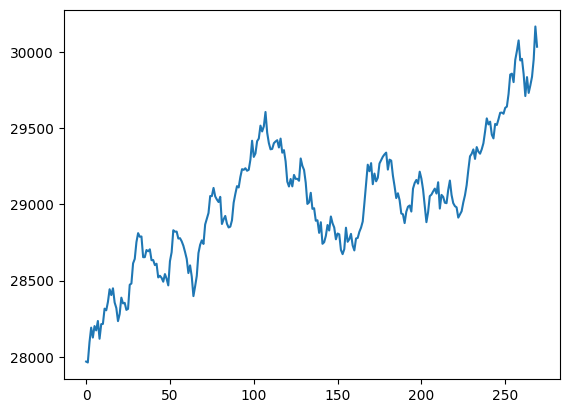

In [8]:
# [7]p営業日後までのシミュレーション実行：単数回
for n in range(1, len(nikkei_F)):
    nikkei_F[n] = bsm(nikkei_F[n-1], sigma, mu, delta_t, random.gauss(mu, sigma))
plt.plot(nikkei_F)

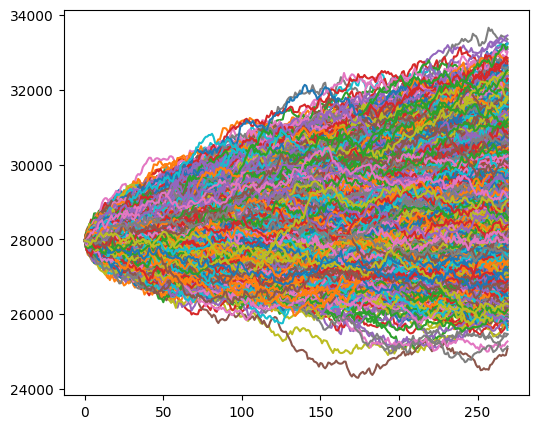

In [9]:
# [8]p営業日後までのシミュレーションをq回実行
plt.figure(figsize=(6, 5))
for i in range(1, q):
    for n in range(1, len(nikkei_F)):
        nikkei_F[n] = bsm(nikkei_F[n-1], sigma, mu, delta_t, random.gauss(mu, sigma))
    plt.plot(nikkei_F)
    nikkei_F2[i] = nikkei_F[-1]
    nikkei_F3 = np.delete(nikkei_F2, 0)

[]

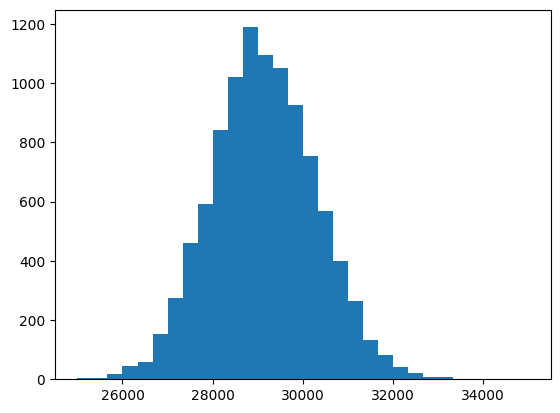

In [10]:
# [9]予測値分布の可視化
plt.hist(nikkei_F3, bins=30, range=(25000, 35000))
plt.plot()

In [11]:
# [10]予測値の記述統計量
print("平均値:", np.mean(nikkei_F3))
print("中央値:", np.median(nikkei_F3))
print("標準偏差:", np.std(nikkei_F3))
print("最小値:", np.min(nikkei_F3))
print("最大値:", np.max(nikkei_F3))

平均値: 29135.41310388461
中央値: 29100.098984867658
標準偏差: 1153.4067658366284
最小値: 25080.94931447316
最大値: 33447.276390879444


### 5.5 時系列モデルによる日経平均株価の予測

In [12]:
# [2]株価データの読み込み
# finance/data/data-main/5_nikkei225_data.csv
nikkei = pd.read_csv(data_path / "5_nikkei225_data.csv", parse_dates=True).sort_index()
nikkei = nikkei.set_index("Date")
nikkei.head()

,nikkei
Date,
2021/1/4,27258.38
2021/1/5,27158.63
2021/1/6,27055.94
2021/1/7,27490.13
2021/1/8,28139.03


In [13]:
# [3]データフレームの整理
nikkei.reset_index(inplace=True)
nikkei["Date"] = pd.to_datetime(nikkei["Date"])
# prophetの変数定義のためリセット
nikkei = nikkei.rename(columns={"Date": "ds", "nikkei": "y"})

### Prophetによる時系列予測モデル

Prophetでは、時系列をトレンド・季節性・祝日効果の加法モデルとして表現します。

$$
y(t) = g(t) + s(t) + h(t) + \varepsilon_t
$$

- $g(t)$: 非線形トレンド（折れ点を含む）
- $s(t)$: 週次・年次などの季節性（フーリエ級数）
- $h(t)$: 祝日やイベントの効果
- $\varepsilon_t$: 誤差項

このノートブックでは、データを `ds`（日付）と `y`（価格）に整形したうえで `fit` し、将来の営業日を生成して予測値を計算します。

01:54:58 - cmdstanpy - INFO - Chain [1] start processing
01:54:58 - cmdstanpy - INFO - Chain [1] done processing
/tmp/prophet-venv/lib/python3.10/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/tmp/prophet-venv/lib/python3.10/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


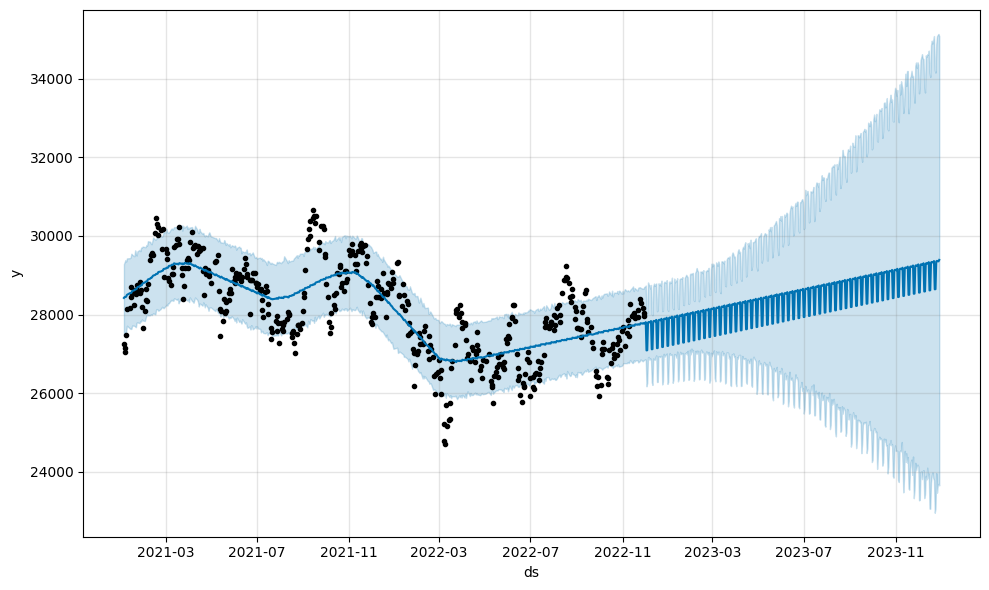

In [14]:
# [4]2023年12月29日の日経平均株価の予測
model = Prophet()
model.fit(nikkei)
future = model.make_future_dataframe(periods=394, freq="d")
forecast = model.predict(future)
model.plot(forecast)
plt.show()